---
---
## Dataset 1: Classification

The dataset, called FARS, is a collection of statistics of US road traffic accidents. The class label (target variable) is about the severity of the accident. It has 20 features and over 100K examples. The dataset can be found in Canvas as a CSV file ("fars.csv"), located alongside this notebook, in which the last column contains the class labels.

## What you need to do:

You will need to perform the following steps on the dataset:
1. EDA
2. Data preprocessing
3. Split the data into training and test sets using cross-validation
4. Develop **FOUR** machine learning pipelines for classifying the severity of the accident
5. Present the results for your pipeline using the most appropriate set of metrics.
6. Provide a short report on which approaches you used and which gave the best results. It would be good to consider why particular pipelines gave the best results.

Some help for good marks:
- We expect that you evaluate a very broad range of options for the design of your machine learning pipelines, including (but not limited to) data preprocessing, feature/instance selection, class imbalance correction, several (appropriate) machine learning pipelines and hyperparameter tuning.


## Your answer below

# *RUN BELOW BEFORE RUNNING EITHER CLASSIFICATION OR REGRESSION TASK*

In [ ]:
pip install --upgrade numpy pandas scikit-learn==1.3.2 imbalanced-learn==0.12.2 ydata-profiling bayesian-optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found exis

In [ ]:
# Imported libraries for all pipelines in classification task
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn import preprocessing
from sklearn.feature_selection import RFE
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt
import ydata_profiling as ydp
from functools import partial
from google.colab import drive

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Define the file path within Google Drive, assuming it's in a 'data' subdirectory
file_path = '/content/drive/MyDrive/Colab Notebooks/Machine_Learning/CSC8635_MINI_coursework/data/fars.csv'  # Corrected path

# Load the dataset
fars_df = pd.read_csv(file_path)

Mounted at /content/drive


# FARS Dataset EDA

In [ ]:
# Showing the Profile Report of the entire dataset
profile = ydp.ProfileReport(fars_df)
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

## FARS EDA Interpretation

Firstly, it's apparent that most of the variables in the dataset are catagorical with only a few items that are either numeric or purley text based. Additionally, majority of the catagorical values shows imbalance towards one or two possible values. A lot of these values are either unknown, a values showing nothing happeneing or other non specified value.

Secondly, the data has specific elements demonstrating a series of tests are applied to the victim of the car accidents. Set up like unknown drug 1-3 or alchohol, it maybe worth looking at how each drug test and result effects the outcome of injury.

Thirdly, a lot of the numerical data shows either a lot of 0s or a lot of a certain high number. The data maybe binary in nature and could allow us to use certain models that use binary explanatory variables.

# General Pipeline Data Pre-processing

It's always beneficial to handle duplicate columns, since 4.8% of the dataset is duplicate rows, we can safely remove them without loosing too much of the overall feature examples. Additionally, since this a single dataset from a single source with no linking required, we do not need to worry too much about loosing any data integrity when removing duplicates. Essentially, in all our pipelines, duplicates would not help so removing them is the best option.

In [ ]:
# Drop Duplicates
fars_df_clean = fars_df.drop_duplicates()

# Size of dataset after duplicate removal
fars_df_clean.shape[0]

93004

# Pipeline 1: Basic Desicion Tree w/ full features using KFold cross validation

It's a good idea to start a ML project with a basic model. In this case, taking the whole dataset, with minimal pre-processing, and using a few simple hyperparameters. Additionally, using a very interpretable model like desicion trees. It's a good fit since the dataset has a lot of catagorial variables that is compatible with the discrete nature of trees. However, despite catagorical variables working well with desicion trees and some language's like R being able to parse the catagorical data directly, pythons' sklearn needs to be encoded via dummy numbers. Finally, using KFold cross validation with grid search to determine which estimators and split of train and test set leads to a better looking model.

In [ ]:
scores = []
predictions = []
actual_labels = []

# X: rest of the features excluding -1 feature
# Y: Target feature which is at -1 (The end column of the dataset)
x = fars_df_clean.iloc[:, :-1]
y = fars_df_clean.iloc[:, -1]

# One-hot encode categorical features in X
X = pd.get_dummies(x, drop_first=True)

# Label Encoding for target feature Y
le = preprocessing.LabelEncoder()
Y = le.fit_transform(y)

# Set the param grid for the cross-validation search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10]
}

# Set the classifier
classifier = DecisionTreeClassifier()

# Main pipeline for fitting and testing the model for n = 5 number of splits
kf = StratifiedKFold(n_splits=5, shuffle=True)
for train_index, test_index in kf.split(X, Y):
  # Generating Partitions for grid search cross validation
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  Y_train, Y_test = Y[train_index], Y[test_index]

  # Grid search of 5 splits using base estimates, scoring using f1_weighted since some features are imbalanced, using 4 multiprocessed jobs to increase runtime performancce
  grid_search = GridSearchCV(classifier, param_grid=param_grid, cv=5, scoring='f1_weighted', verbose=0, n_jobs=4)
  grid_search.fit(X_train, Y_train)

  # Looks at the depth of each tree based on each grid search split
  estimator = grid_search.best_estimator_
  print("Max depth of Desicion Tree: {0}".format(estimator.max_depth))

  # Capture the prediction score with the best estimate
  pred = estimator.predict(X_test)
  scores.append(metrics.f1_score(Y_test, pred, average='weighted'))

  # Get the prediction probability of predicting the class label
  pred_prob = estimator.predict_proba(X_test)
  predictions.append(pred_prob)
  actual_labels.append(Y_test)

Max depth of Desicion Tree: 10
Max depth of Desicion Tree: 10
Max depth of Desicion Tree: 10
Max depth of Desicion Tree: 10
Max depth of Desicion Tree: 10


## Pipeline 1 Evaluation

For a classification model with such imbalenced data it's best to use metrics that can handle such imbalence. In this case we already have weighted F1 scores for each model split, looking at the average will give a good impression of the general success. Additionally, since we have a multi-class problem, we need to calculate a micro-averaged PR curve. In this case we need to concatenate each folds predictive and actual labels, get the number of classes, binarize the true labels and use this with the probability of prediction to form the curve.

Average weighted f1 score 0.7702234948179345
Area Under Precision-Recall Curve 0.9030449204554692


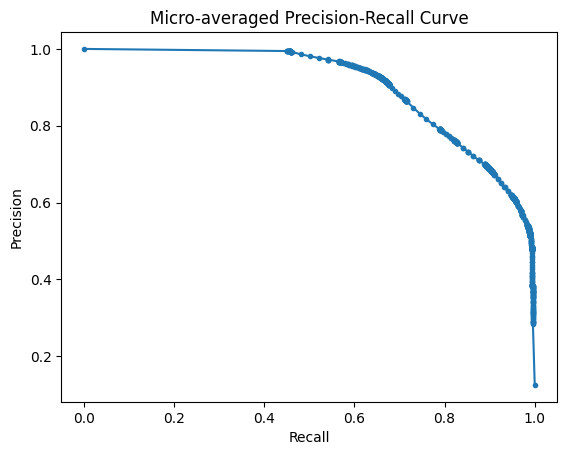

In [ ]:
# Gives the overall score of each model
print("Average weighted f1 score {0}".format(np.average(scores)))

# Concatenate actual labels and predictions from all folds
all_y_true = np.concatenate(actual_labels)
all_y_pred_proba = np.concatenate(predictions, axis=0)

# Determine the number of classes from the predicted probabilities or actual labels
n_classes = all_y_pred_proba.shape[1] # Assumes predictions contain probabilities for all classes

# Binarize the true labels for multi-class PR curve (one-hot encoding)
y_true_binarized = preprocessing.label_binarize(all_y_true, classes=np.arange(n_classes))

# Compute micro-averaged precision-recall curve
prec, recall, _ = metrics.precision_recall_curve(y_true_binarized.ravel(), all_y_pred_proba.ravel())
print("Area Under Precision-Recall Curve {0}".format(metrics.auc(recall, prec)))

# Plot the precision-recall graph
plt.plot(recall, prec, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Micro-averaged Precision-Recall Curve")
plt.show()

**Interpretation:**

The model from initial inspection seems rather good. The graph shows a fairly clear curve that suggests that as the recall increases (more positives) the precision decreases (most false positives). This particular curve is quite close to 1 precision, 1 recall, which in perfect cases would make a very strong model. Whats being shown is that we can get a high precision without sacraficing too much recall. This makes sense since the weighted f1 score suggests a good model for most classification problems. Moreover, since we are using micro-averaged data, due to high imbalence, the predicitons are treated equally but not the classes themselves. Maybe we can create a model with more optimised hyperparameters, better selected features or more balanced features.

# Pipeline 2: Decision tree w/ Bayesian optimised hyperparameters

Upon reflection and small research there is something not quite right about the previos model. Firstly, there wasn't enough hyperparameter combinations being tested for each model. Secondly, the CV search with k-fold cross validation kept choosing max_depth at 10. It suggests the potential of overfitting noisy and imbalanced data rather than generalising to patterns. For this model Bayesian Optimisation will be applied to the hyperparameters to see if we can better tune them.

In [ ]:
# Optimisation function using cross validation
def dtree_cv(max_depth, min_samples_split, min_samples_leaf, X_train, Y_train):
  # Define the model with parameters needing to be optimised
  estimator = DecisionTreeClassifier(
      max_depth=int(max_depth),
      min_samples_split=int(min_samples_split),
      min_samples_leaf=int(min_samples_leaf),
      random_state=2
  )
  cval = cross_val_score(estimator, X_train, Y_train, scoring='f1_weighted', cv=5)
  return cval.mean()

Once we have the optimisation function set up, we now need to perform the pipeline as normal

In [ ]:
scores=[]
predictions=[]
actual_labels=[]

# Exact same code, preparing the data
x = fars_df_clean.iloc[:, :-1]
y = fars_df_clean.iloc[:, -1]

X = pd.get_dummies(x, drop_first=True)

le = preprocessing.LabelEncoder()
Y = le.fit_transform(y)

# Similar Pipeline setup
kf = StratifiedKFold(n_splits=5, shuffle=True)
for fold, (train_index, test_index) in enumerate(kf.split(X, Y)):
  print(f"Processing Fold {fold+1}/5")
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  Y_train, Y_test = Y[train_index], Y[test_index]

  # Set a new param grid with bounds corresponding with our function
  param_grid = {
    'max_depth': (1, 20),
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 20)
  }

  # Use partial to bind X_train and Y_train to dtree_cv
  bound_dtree_cv = partial(dtree_cv, X_train=X_train, Y_train=Y_train)

  # Initialises the parameters for our optimisation function
  optimizor = BayesianOptimization(
      f=bound_dtree_cv, # Pass the partially applied function
      pbounds=param_grid,
      random_state=2
  )

  # Maximises the weighted f1 score for the optimisation parameters
  optimizor.maximize(init_points=25, n_iter=5)

  # Print the best parameters for this run
  best_parameters = optimizor.max['params']
  # Ensure integer hyperparameters are cast correctly
  best_parameters['max_depth'] = int(best_parameters['max_depth'])
  best_parameters['min_samples_split'] = int(best_parameters['min_samples_split'])
  best_parameters['min_samples_leaf'] = int(best_parameters['min_samples_leaf'])
  print(f"Best Decision Tree Parameters for Fold {fold+1}: {best_parameters}")

  # Reconstruct the best estimator using the optimized parameters
  best_estimator = DecisionTreeClassifier(
      max_depth=best_parameters['max_depth'],
      min_samples_split=best_parameters['min_samples_split'],
      min_samples_leaf=best_parameters['min_samples_leaf'],
      random_state=2
  )
  # Fit the best estimator on the training data for the current fold
  best_estimator.fit(X_train, Y_train)

  # Make prediction using the optimised estimator
  pred = best_estimator.predict(X_test)
  scores.append(metrics.f1_score(Y_test, pred, average='weighted'))

  # Append the probability of classifying the right label
  pred_prob = best_estimator.predict_proba(X_test)
  predictions.append(pred_prob)
  actual_labels.append(Y_test)


Processing Fold 1/5
|   iter    |  target   | max_depth | min_sa... | min_sa... |
-------------------------------------------------------------
| 1         | 0.7488442 | 9.2839031 | 2.4666721 | 11.443587 |
| 2         | 0.7475145 | 9.2711254 | 9.5666204 | 7.2763615 |
| 3         | 0.7352204 | 4.8883240 | 13.146877 | 6.6934387 |
| 4         | 0.7353108 | 6.0697182 | 13.180408 | 11.053699 |
| 5         | 0.6952951 | 3.5570189 | 11.244406 | 4.5043574 |
| 6         | 0.7348852 | 15.921367 | 17.371555 | 10.390499 |
| 7         | 0.7333902 | 17.084668 | 3.4336185 | 10.599675 |
| 8         | 0.6783034 | 2.2404435 | 9.7062018 | 2.8340873 |
| 9         | 0.6952951 | 3.4160394 | 12.741415 | 5.2942280 |
| 10        | 0.6952951 | 3.0319680 | 5.9655117 | 7.6466994 |
| 11        | 0.7486813 | 9.8879622 | 5.6313780 | 13.167727 |
| 12        | 0.7473718 | 10.178326 | 11.094260 | 8.3509603 |
| 13        | 0.7274630 | 16.079111 | 12.440075 | 4.0836733 |
| 14        | 0.7431824 | 14.314294 | 19.361919 | 

**Model Explanation:**
Similar to our last model, the difference is using a bayesian optimisation tool to maximise some function, in this case the function is the weighted f1 score of the Desicion Tree Classifier. What is happening is each iteration is testing a set of parameters that are bound within our parameter grid values. These parameters are iterativley changed to get the best score, using bayesian posterior and prior analysis on the parameters (who have a certain distribution). For each k-fold we output the best parameter combination.

## Pipeline 2 Evaluation

Average weighted f1 score 0.7676159831747768
Area Under Precision-Recall Curve 0.9050930754921139


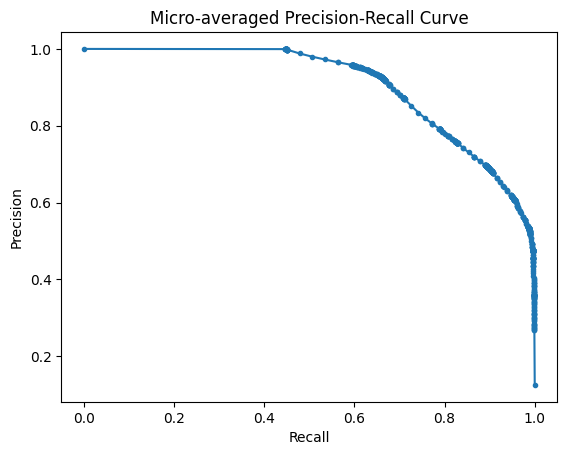

In [ ]:
# The same evaluation procedure and metrics are used in our initial pipeline analysis
print("Average weighted f1 score {0}".format(np.average(scores)))

all_y_true = np.concatenate(actual_labels)
all_y_pred_proba = np.concatenate(predictions, axis=0)

n_classes = all_y_pred_proba.shape[1]

y_true_binarized = preprocessing.label_binarize(all_y_true, classes=np.arange(n_classes))

prec, recall, _ = metrics.precision_recall_curve(y_true_binarized.ravel(), all_y_pred_proba.ravel())
print("Area Under Precision-Recall Curve {0}".format(metrics.auc(recall, prec)))

plt.plot(recall, prec, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Micro-averaged Precision-Recall Curve")
plt.show()

**Interpretation:**

The resulting curve and values seem to be almost identical to the first pipeline evaluation. There are 2 conclusions that could be made. Either, the hyperparameter bayesian optimisation was an over-engineered solution to a small problem and we already had a fairly good set of hyperparameters. On the other hand, maybe the evaluation curve is not showing the individual success of each predicted label and just using the overall result. Next time, we should think about using Random Forest as our algorithm, to see the potential differences and alter our evaluation to show the result of classifiying each label.

# Pipeline 3: Random Forest w/ random hyperparameters & select features

Exploring the data further, it seems there is a lot of features that may seem less important than others. Our previous pipeline ran quite slow as it was optimising the hyperparameters. In this model, the focus will be on performing feature selection before training the model. To save on run-time the hyperparameters will be randomly selected to just focus on the consequences of selecting features. Random Forest will be used to both feature select and be our training model, this is because its an ensamble method that picks up certain aspects which raw desicion trees lack. For example, using trees are inherintly linear, the random forest allows for deeper digging into establishing non-linear relationships. Additionally, using this method of feature selection allows us to observe an intrinsic ranking of features that we can use in our evaluated model. For the sake of this model, the top 10 important features are going to be used to train the model.

In [ ]:
# IMPORTANT: need to use high RAM to run

scores=[]
predictions=[]
actual_labels=[]

# Exact same code, preparing the data
x = fars_df_clean.iloc[:, :-1]
y = fars_df_clean.iloc[:, -1]

X = pd.get_dummies(x, drop_first=True)

le = preprocessing.LabelEncoder()
Y = le.fit_transform(y)

# Search grid for random hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# Similar Pipeline setup
kf = StratifiedKFold(n_splits=5, shuffle=True)
for fold, (train_index, test_index) in enumerate(kf.split(X, Y)):
  print(f"Processing Fold {fold+1}/5")
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  Y_train, Y_test = Y[train_index], Y[test_index]

  # For each fold, perform an initial Random Forest search to get the feature importance (FEATURE SELECTION)
  rf_classifier = RandomForestClassifier(random_state=2)
  rf_classifier.fit(X_train, Y_train)

  # Extract the importance of the feature importances
  feature_importances = rf_classifier.feature_importances_
  feature_names = X.columns
  feature_importances_table = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

  # Sort the features in importance order and print the first 10
  feature_importances_table = feature_importances_table.sort_values(by='Importance', ascending=False)
  print(feature_importances_table.head(10))

  # Select the top 10 features
  top_features = feature_importances_table['Feature'][:10].values
  X_train_selected = X_train[top_features]
  X_test_selected = X_test[top_features]

  # For each fold, perform some random hyperparameter tuning (HYPERPARAMETER TUNING)
  # Perform the randomised search, fit the model, print best estimator
  random_search = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=param_grid, scoring='f1_weighted', cv=5, n_jobs=-1)
  random_search.fit(X_train_selected, Y_train)
  print(random_search.best_estimator_)

  # For each fold, predict using the best estimator with the best features (PREDICT AND COLLECT)
  pred = random_search.predict(X_test_selected)
  scores.append(metrics.f1_score(Y_test, pred, average='weighted'))

  pred_prob = random_search.predict_proba(X_test_selected)
  predictions.append(pred_prob)
  actual_labels.append(Y_test)

Processing Fold 1/5
                                             Feature  Importance
0                                                AGE    0.166644
197                            TAKEN_TO_HOSPITAL_Yes    0.133142
331             RACE_Not_a_Fatality_(Not_Applicable)    0.116238
193  HISPANIC_ORIGIN_Not_a_Fatality_(Not_Applicable)    0.109953
192                     HISPANIC_ORIGIN_Non-Hispanic    0.040929
195                          HISPANIC_ORIGIN_Unknown    0.034140
337                                       RACE_White    0.031422
335                                     RACE_Unknown    0.029947
1                                ALCOHOL_TEST_RESULT    0.016985
55                                          SEX_Male    0.016491
RandomForestClassifier(min_samples_split=5)
Processing Fold 2/5
                                             Feature  Importance
0                                                AGE    0.167052
197                            TAKEN_TO_HOSPITAL_Yes    0.134008
193  H

**Model Interpretation:**
Firstly, this pipeline struggled to complete execution under a CPU, had to change it to a high RAM GPU in order to run. Secondly, each feature selection table showed pretty much the same 10 important features, which could suggest that performing feature selection is beneficial and that it's not particularly dependent on the k-fold test-train split. Finally, the random search cv showcased that many hyperparameters wern't tested (including using just a basic classifier), this could be more thourgh.

## Pipeline 3 Evaluation

Average weighted f1 score 0.7209542165271456


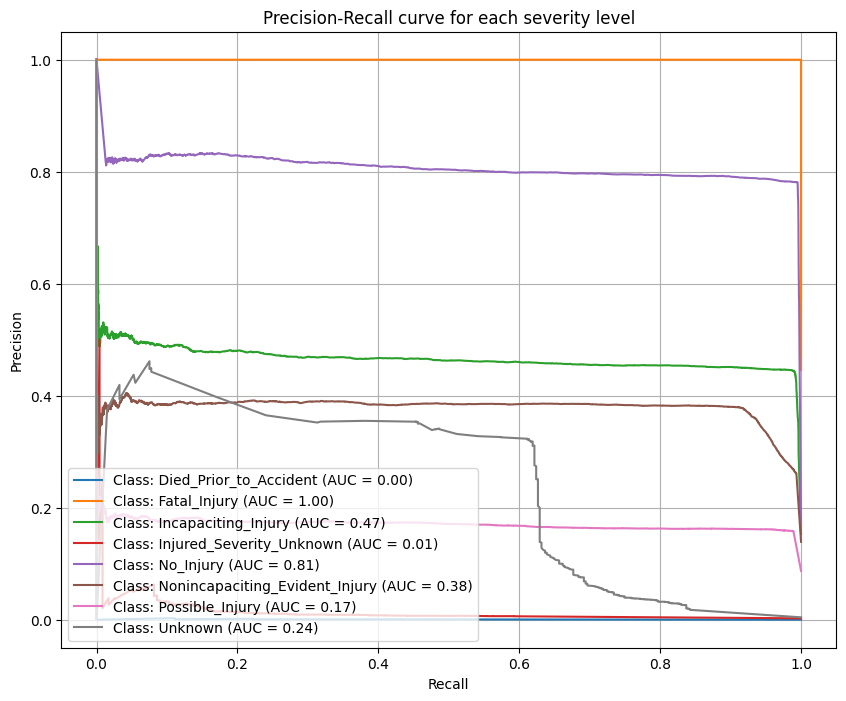

In [ ]:
# The same evaluation procedure and metrics are used in our initial pipeline analysis
print("Average weighted f1 score {0}".format(np.average(scores)))

all_y_true = np.concatenate(actual_labels)
all_y_pred_proba = np.concatenate(predictions, axis=0)

n_classes = all_y_pred_proba.shape[1]

y_true_binarized = preprocessing.label_binarize(all_y_true, classes=np.arange(n_classes))

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    precision, recall, _ = metrics.precision_recall_curve(y_true_binarized[:, i], all_y_pred_proba[:, i])
    auc_score = metrics.auc(recall, precision)

    # Get the original class name from the LabelEncoder
    class_name = le.inverse_transform([i])[0]

    plt.plot(recall, precision, label=f'Class: {class_name} (AUC = {auc_score:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve for each class label")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

**Interpretation:**

It's very beneficial to view the individual PR curves for each class label. It shows how good the model is at predicting certain labels and therefore gives us an idea of any overfitted or underfitted labels. In this case we have a variaty of both, for example having AUC of 0 or 1 shows major overfitting and underfitting. Additionally, seems to be a lot of predicted unkowns and heavy emphises on the No_Injury class label. Looking at this result, shows to me, we need to deal with class imbalence, remove some of the class labels that predict unkown results and keep using Bayesian Optimisation on the hyperparameters.

# Pipeline 4: Random Forest w/ class balencing and bayesian optimisation

Upon additional research, it's clear to me the main problems with all the previous pipelines is the class imbalencing issues. The previous pipeline showcased just how flawed our model is with the dataset we have. This pipeline is going to focus on using a techniques called synthetic minority oversampling (SMOTE), alongside already test techniques that seemed to help with the model. Additionally, it would be good to test out the pipeline function from the imbalence library. Finally, to avoid long computation time, instead of finding the top 10 most important features after running our classifier, we use Recursive Feature Elimination (RFE) to get our top 10.

In [ ]:
# Optimisation function using cross validation
def rforest_cv(n_estimators, max_depth, min_samples_split, min_samples_leaf, X_train, Y_train):
  # Define the model with parameters needing to be optimised
  estimator = RandomForestClassifier(
      n_estimators=int(n_estimators),
      max_depth=int(max_depth),
      min_samples_split=int(min_samples_split),
      min_samples_leaf=int(min_samples_leaf),
      random_state=2
  )
  # Use n_jobs=-1 to utilize all available CPU cores for parallel processing
  cval = cross_val_score(estimator, X_train, Y_train, scoring='f1_weighted', cv=5, n_jobs=-1)
  return cval.mean()

Once the function to optimise has been implemented, we need to set up the pipeline

In [ ]:
# IMPORTANT: TOOK 45MIN TO COMPLETE
scores = []
predictions = []
actual_labels = []

# x for features, y for predicted labels
x = fars_df_clean.iloc[:, :-1]
y = fars_df_clean.iloc[:, -1]

X = pd.get_dummies(x, drop_first=True)

le = preprocessing.LabelEncoder()
Y = le.fit_transform(y)

# Balence the dataset with an even frequency of each class
balencer = SMOTE(sampling_strategy='not majority', random_state=2)
X_res, Y_res = balencer.fit_resample(X, Y);

kf = StratifiedKFold(n_splits=5, shuffle=True)
for fold, (train_index, test_index) in enumerate(kf.split(X_res, Y_res)):
  print(f"Processing Fold {fold+1}/5")
  X_train, X_test = X_res.iloc[train_index], X_res.iloc[test_index]
  Y_train, Y_test = Y_res[train_index], Y_res[test_index]

  # Hyperparameter bounds to use as input for optimisation
  param_grid = {
    'n_estimators': (100, 200),
    'max_depth': (1, 20),
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 20),
  }

  # Partially bind and instantiate the optimisor
  bound_rforest_cv = partial(rforest_cv, X_train=X_train, Y_train=Y_train)
  optimizor = BayesianOptimization(
      f=bound_rforest_cv,
      pbounds=param_grid,
      random_state=2
      #verbose=0 # Set verbose to 0 to reduce output during optimization
  )

  # Find the maximum and use those hyperparameters in the classifier
  optimizor.maximize(n_iter=5)
  best_parameters = optimizor.max['params']
  best_parameters['n_estimators'] = int(best_parameters['n_estimators'])
  best_parameters['max_depth'] = int(best_parameters['max_depth'])
  best_parameters['min_samples_split'] = int(best_parameters['min_samples_split'])
  best_parameters['min_samples_leaf'] = int(best_parameters['min_samples_leaf'])
  print(f"Best Random Forest Parameters for Fold {fold+1}: {best_parameters}")

  best_classifier_estimators = RandomForestClassifier(
      n_estimators=best_parameters['n_estimators'],
      max_depth=best_parameters['max_depth'],
      min_samples_split=best_parameters['min_samples_split'],
      min_samples_leaf=best_parameters['min_samples_leaf'],
      random_state=2,
      n_jobs=-1
  )

  # Create the pipeline to perform RFE feature selection -> classifier
  # Modified step to remove 10% of features at each iteration
  selector = RFE(estimator=best_classifier_estimators, n_features_to_select=10, step=0.1)
  pipeline = Pipeline([
      ('selector', selector),
      ('classifier', best_classifier_estimators)
  ])

  # Fit and accumulate results
  pipeline.fit(X_train, Y_train)

  pred = pipeline.predict(X_test)
  scores.append(metrics.f1_score(Y_test, pred, average='weighted'))

  pred_prob = pipeline.predict_proba(X_test)
  predictions.append(pred_prob)
  actual_labels.append(Y_test)

Processing Fold 1/5
|   iter    |  target   | n_esti... | max_depth | min_sa... | min_sa... |
-------------------------------------------------------------------------
| 1         | 0.5409748 | 143.59949 | 1.4925984 | 11.893924 | 9.2711254 |
| 2         | 0.6409732 | 142.03678 | 7.2763615 | 5.6836754 | 12.766148 |
| 3         | 0.6279886 | 129.96546 | 6.0697182 | 13.180408 | 11.053699 |
| 4         | 0.6653998 | 113.45799 | 10.757984 | 5.3199175 | 15.921367 |
| 5         | 0.6701342 | 185.39752 | 10.390499 | 17.238106 | 2.5132640 |
| 6         | 0.6951629 | 159.67453 | 14.524407 | 2.9794005 | 11.383338 |
| 7         | 0.6734685 | 117.40553 | 11.209374 | 13.705261 | 13.391971 |
| 8         | 0.6899065 | 159.66651 | 13.588043 | 2.1369765 | 11.512762 |
| 9         | 0.7141809 | 152.55167 | 20.0      | 2.6649426 | 16.107985 |
| 10        | 0.7108787 | 161.99859 | 20.0      | 11.053422 | 20.0      |
Best Random Forest Parameters for Fold 1: {'n_estimators': 152, 'max_depth': 20, 'min_sample

## Pipeline 4 Evaluation

Average weighted f1 score 0.6234192087402709
Area Under Precision-Recall Curve 0.781728877041272


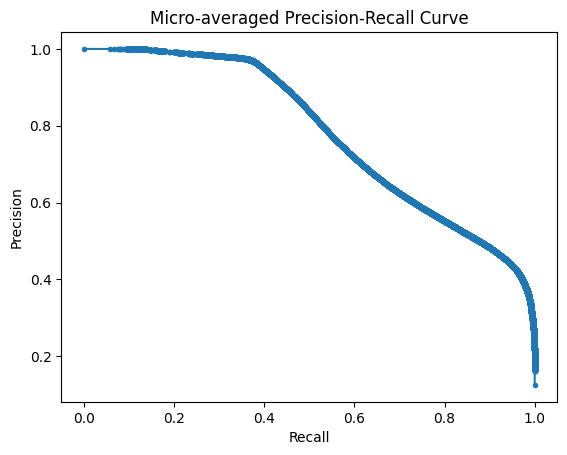

In [ ]:
# The same evaluation procedure and metrics are used in our initial pipeline analysis
print("Average weighted f1 score {0}".format(np.average(scores)))

all_y_true = np.concatenate(actual_labels)
all_y_pred_proba = np.concatenate(predictions, axis=0)

n_classes = all_y_pred_proba.shape[1]

y_true_binarized = preprocessing.label_binarize(all_y_true, classes=np.arange(n_classes))

prec, recall, _ = metrics.precision_recall_curve(y_true_binarized.ravel(), all_y_pred_proba.ravel())
print("Area Under Precision-Recall Curve {0}".format(metrics.auc(recall, prec)))

plt.plot(recall, prec, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Micro-averaged Precision-Recall Curve")
plt.show()

**Interpretation**

This seems like a much more accurate PR-curve and not as optimistic as previous PR-curves. The effect of balancing our classes has certainly had an effect, alongside using RFE as our feature selection. It would be beneficial to look at the PR-curve for each predicted label.

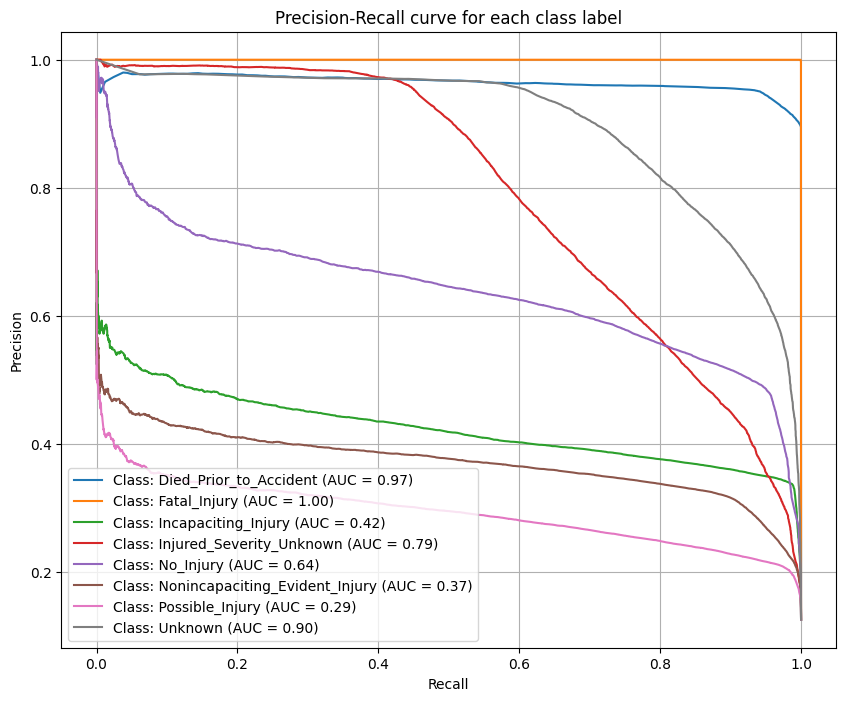

In [ ]:
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    precision, recall, _ = metrics.precision_recall_curve(y_true_binarized[:, i], all_y_pred_proba[:, i])
    auc_score = metrics.auc(recall, precision)

    # Get the original class name from the LabelEncoder
    class_name = le.inverse_transform([i])[0]

    plt.plot(recall, precision, label=f'Class: {class_name} (AUC = {auc_score:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve for each class label")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

**Interpretation**

Looks very positive, the model is doing a much better job at predicting a variety of the class labels. Although the AUC values for certain classes are still quite low demonstrating a lot of mis-classification its still an improvement from our previous pipelines.

---
---
## Dataset 2: Regression

In this part of the coursework you are going to look at a regession problem - predicting the growth rate of a bacteria. The provided dataset contains results from a set of experiments where we grew bacteria of different strains and under different conditions (CO2 availability, light, etc..) to compute a growth curve for the bacteria - represented by the variables 'a', 'mu', 'tau' and 'a0'. Your job is to predict the results of the experiment - 'a', 'mu', 'tau' and 'a0' (these are the growth-rate parameters for the bacteria, but you don't need to understand the details to do the coursework).

The dataset is available in Canvas as a CSV file ("fitting-results.csv"), in the same location where you downloaded this notebook.

The CSV contains 9 fields as follows:

| variable | description |
|-----|------|
| n_cyanos | The number of Cyanobacteria available at the start |
| co2 | The amount of CO2 available |
| light | The amount of light available |
| SucRatio | How good the bacteria is at producing sucrose |
| Nsample | Experiment number |
| a | Maximum number of bacteria seen (Target variable) |
| mu | Growth rate of bacteria (Target variable) |
| tau | Time delay before bacteria starts growing (Target variable) |
| a0 | Initial level of bacteria (Target variable) |

## What you need to do:

You will need to perform the following steps on the dataset:
1. EDA
2. Data preprocessing
3. Split the data into train/test/validate
4. Develop **FOUR** machine learning pipelines for predicting 'a', 'mu', 'tau' and 'a0'. This should include hyperparameter tuning. Note: This is not four pipelines one for 'a' one for 'mu'... but four pipelines for 'a', four for 'mu'...
5. Present the results for your pipelines using the most appropriate set of metrics.
6. Provide a short report on which approaches you used and which gave the best results. It would be good to consider why particular pipelines gave the best results.

Some help for good marks:
- Make sure that when you predict 'a' you don't have 'mu', 'tau' or 'a0' in your features - this would make it very easy to predict but be compleatly wrong.
- Remember that this is a **regression** problem and use models that are appropriate for this.
- Hyperparameters can be crucial to get good results here.

## Your answer below

In [ ]:
# Imported libraries for all the pipelines in Regression task
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ydata_profiling as ydp
from google.colab import drive
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Define the file path within Google Drive, assuming it's in a 'data' subdirectory
file_path = '/content/drive/MyDrive/Colab Notebooks/Machine_Learning/CSC8635_MINI_coursework/data/fitting-results.csv'  # Corrected path

# Load the dataset
fitting_results_df = pd.read_csv(file_path)

Mounted at /content/drive


# Fitting Results EDA

In [ ]:
# Showing the Profile Report of the entire dataset
profile = ydp.ProfileReport(fitting_results_df)
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

## Fitting Results EDA Interpretation

A much smaller dataset than our FARS data, seems to be exclusivley made of numerical features with no duplicates. The varience of the features are probably the most important finding from this EDA evaluation.

Firstly, our target variables a and mu have a very similar mean average with a very left-skewed distribution of values. A and mu also have a very wide spread of data examples going from very very small to large. It suggests to me that these variables are highly correlated and very similar distribtuion. This could lead to multicollinerity problems in our regression model, however we are soley focused on predicition and may saftely ignore the unique effect of variables on our predicter.

Secondly, we have 2 other target variables tao and a0. These are less correlated values with vary different scale of spread in the data.

# General Pipeline Data Pre-processing

It's clear that we might need to normalise the scale of our data, this would be our general data pre-processing since similar scales will lead to better fitted data. Since the Explanatory variables seem to have vary different scales and the target variables have skewed distribtuions and a lot of outliers, Robust Scaling would be a good feature scaling technique. Robust Scaling, uses the median of the features and Inter-Quatile range so the features scale to 50% within its median. This makes the scaling very robust to outliers and skews.

In [ ]:
# Set instance of scaler
scaler = RobustScaler()

# Fit scale and translate back to data frame
fitting_results_data_scaled = scaler.fit_transform(fitting_results_df)
fitting_results_df_scaled = pd.DataFrame(fitting_results_data_scaled, columns=fitting_results_df.columns)

# Pipeline 1: Linear Regression with random hyperparameters

Similar to our classification problem, it's good to start with something really simple and grow from there. In this case, we want 4 mini-pipelines to regress each target variable linearly with no hyperparameter tuning to see how well the pipeline does on the data with no optimisation.

## Pipeline 1.1 feature a

Regression Coefficients:  [-2.93163017e+00  1.39241376e+00 -6.86940531e-04 -1.28198345e+00
 -3.03638627e-03]
Varience Score:  0.28044636118788735


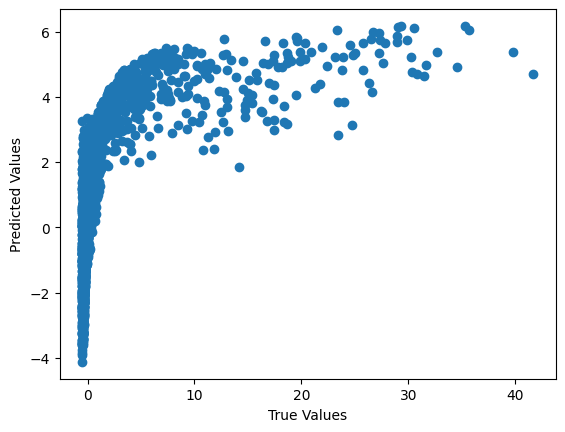

In [ ]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a', 'mu', 'tau', 'a0'], axis=1)
Y = fitting_results_df_scaled.filter(['a']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit the data
linear_reg = LinearRegression()
linear_reg.fit(X_train, Y_train)

# Print Regression Coefficients
print("Regression Coefficients: ", linear_reg.coef_)

# Print Varience Score
print("Varience Score: ", linear_reg.score(X_test, Y_test))

# Plot predicted values
plt.scatter(Y_test, linear_reg.predict(X_test))
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()

## Pipeline 1.2 feature mu

Regression Coefficients:  [-9.50520234e-02  6.50500327e-02  1.06395534e-02 -2.24433259e-01
  5.04655555e-06  8.24514817e-01 -1.63366155e-01  1.86611791e-02]
Varience Score:  0.9943364606747412


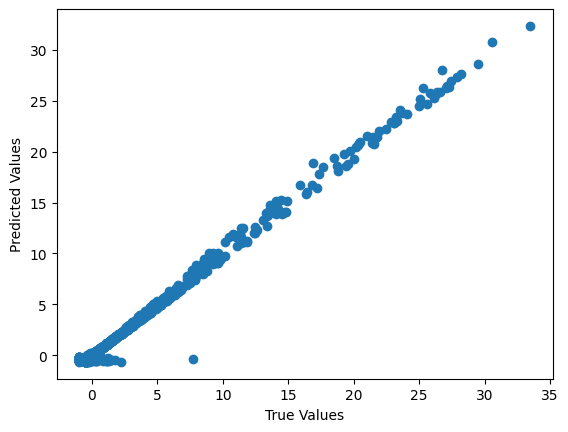

In [ ]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['mu'], axis=1)
Y = fitting_results_df_scaled.filter(['mu']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit the data
linear_reg = LinearRegression()
linear_reg.fit(X_train, Y_train)

# Print Regression Coefficients
print("Regression Coefficients: ", linear_reg.coef_)

# Print Varience Score
print("Varience Score: ", linear_reg.score(X_test, Y_test))

# Plot predicted values
plt.scatter(Y_test, linear_reg.predict(X_test))
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()

## Pipeline 1.3 feature tau

Regression Coefficients:  [-0.57166167  0.4241545   0.00633159 -0.24942567 -0.00925191  0.38806058
 -0.27810488  0.03509367]
Varience Score:  0.9150607712223044


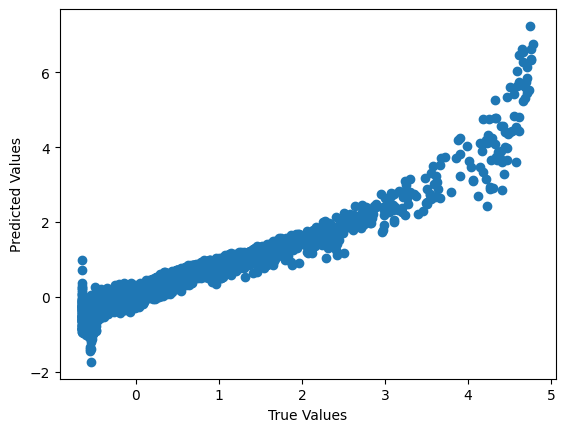

In [ ]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['tau'], axis=1)
Y = fitting_results_df_scaled.filter(['tau']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit the data
linear_reg = LinearRegression()
linear_reg.fit(X_train, Y_train)

# Print Regression Coefficients
print("Regression Coefficients: ", linear_reg.coef_)

# Print Varience Score
print("Varience Score: ", linear_reg.score(X_test, Y_test))

# Plot predicted values
plt.scatter(Y_test, linear_reg.predict(X_test))
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()

## Pipeline 1.4 feature a0

Regression Coefficients:  [-0.05667619  0.44359294 -0.0233924  -0.19129984  0.01801451 -2.00624126
  2.00935521  2.15464666]
Varience Score:  0.2941386681835386


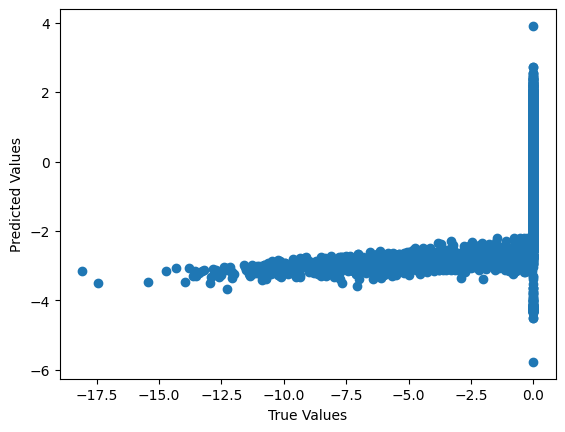

In [ ]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a0'], axis=1)
Y = fitting_results_df_scaled.filter(['a0']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit the data
linear_reg = LinearRegression()
linear_reg.fit(X_train, Y_train)

# Print Regression Coefficients
print("Regression Coefficients: ", linear_reg.coef_)

# Print Varience Score
print("Varience Score: ", linear_reg.score(X_test, Y_test))

# Plot predicted values
plt.scatter(Y_test, linear_reg.predict(X_test))
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()

# Pipeline 1 overall Evaluation

Firstly, feature a is terribly fitted to the explanatory variables. The scatter shows a clear curve where most of the predicted values are not fit to the true values. Suggests to me the regression model is wrong and optimisation is important.

Secondly, feature mu and tao seem to have fit rather well the data. Most likely, the data is overfit and the general pattern of the data is not taken into consideration.

Finally, a0 which looks as if its gone completely wrong. It's definate that the relationship isn't linear and more advanced models need to be considered.

# Pipeline 2: Optimised Linear Regression

Using such a basic model like Linear Regression can have various problems like Mulitcolinearity and highly overfitted coefficients which can make the model terrible at generalising to new data. In this pipeline, the aim is to make improvements on the Linear Regression model to see if our predicted values get any better (especially with a and a0). To do this, we use Stochastic Gradient Descent with Lasso Regularization, to eliminate coefficients that are too low (close to 0). A loss function is used to determine how wrong the fit is and adjusts coefficients based on their absolute values. The effect is a more generalised model with less overfitting, we just have to ensure highly correlated features are removed.

## Pipeline 2.1 feature a

Regression Coefficients:  [-2.90292439  1.39292903 -0.07598531 -1.29621723 -0.07239305]
Varience Score:  0.28011701949658074


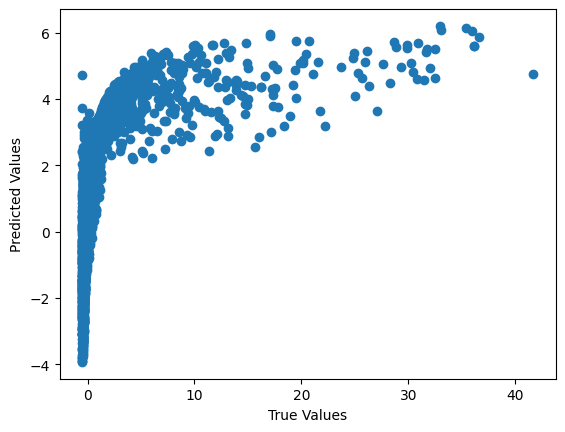

In [ ]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a', 'mu', 'tau', 'a0'], axis=1)
Y = fitting_results_df_scaled.filter(['a']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit the data
sgd_reg = SGDRegressor(penalty="l1")
sgd_reg.fit(X_train, Y_train)

# Print Regression Coefficients
print("Regression Coefficients: ", sgd_reg.coef_)

# Print Varience Score
print("Varience Score: ", sgd_reg.score(X_test, Y_test))

# Plot predicted values
plt.scatter(Y_test, sgd_reg.predict(X_test))
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()

## Pipeline 2.2 feature mu

Regression Coefficients:  [-2.39039722  1.11118897  0.0360867  -1.26296467 -0.02028271]
Varience Score:  0.305293081143604


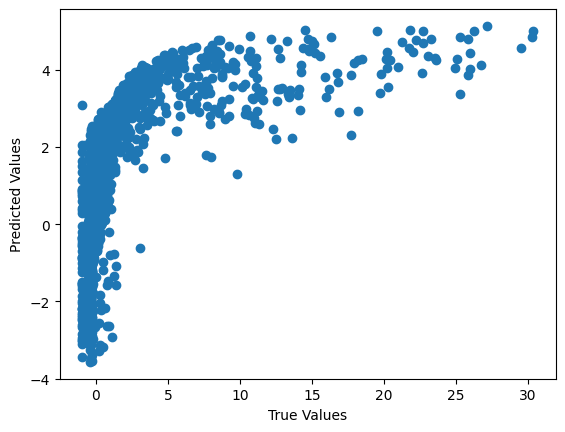

In [ ]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a', 'mu', 'tau', 'a0'], axis=1)
Y = fitting_results_df_scaled.filter(['mu']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit the data
sgd_reg = SGDRegressor(penalty="l1")
sgd_reg.fit(X_train, Y_train)

# Print Regression Coefficients
print("Regression Coefficients: ", sgd_reg.coef_)

# Print Varience Score
print("Varience Score: ", sgd_reg.score(X_test, Y_test))

# Plot predicted values
plt.scatter(Y_test, sgd_reg.predict(X_test))
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()

## Pipeline 2.3 feature tau

Regression Coefficients:  [-1.10346255  0.71314396  0.         -0.44627985 -0.00934057]
Varience Score:  0.6111687264023926


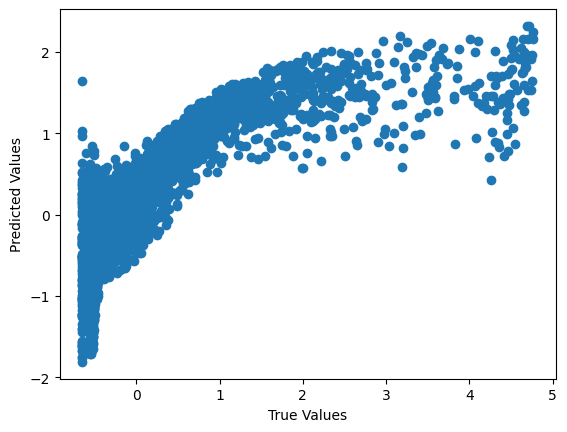

In [ ]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a', 'mu', 'tau', 'a0'], axis=1)
Y = fitting_results_df_scaled.filter(['tau']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit the data
sgd_reg = SGDRegressor(penalty="l1")
sgd_reg.fit(X_train, Y_train)

# Print Regression Coefficients
print("Regression Coefficients: ", sgd_reg.coef_)

# Print Varience Score
print("Varience Score: ", sgd_reg.score(X_test, Y_test))

# Plot predicted values
plt.scatter(Y_test, sgd_reg.predict(X_test))
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()

## Pipeline 2.4 feature a0

Regression Coefficients:  [-1.30028651  1.45608347 -0.02613903 -1.05820188 -0.02311827]
Varience Score:  0.21533227142912714


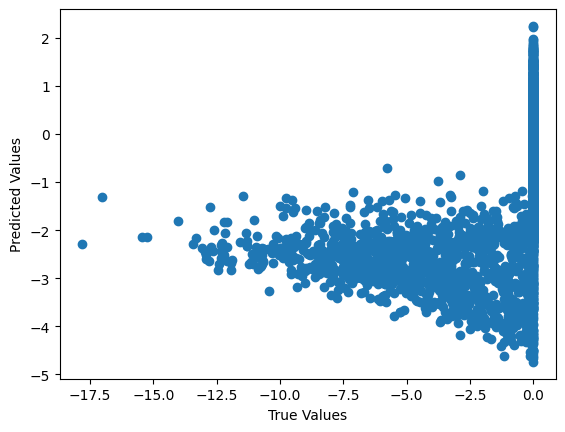

In [ ]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a', 'mu', 'tau', 'a0'], axis=1)
Y = fitting_results_df_scaled.filter(['a0']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit the data
sgd_reg = SGDRegressor(penalty="l1")
sgd_reg.fit(X_train, Y_train)

# Print Regression Coefficients
print("Regression Coefficients: ", sgd_reg.coef_)

# Print Varience Score
print("Varience Score: ", sgd_reg.score(X_test, Y_test))

# Plot predicted values
plt.scatter(Y_test, sgd_reg.predict(X_test))
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.show()

# Pipeline 2 overall Evaluation

There is clear and obvious proof our data is nowhere near suited to Linear Regression, from now on, we should look at more complex models like Support Vectior Regression and Random Forest Regression.

# Pipeline 3 Support Vector Regression w/ Optimised Hyperparameters

The primariy goal with this pipeline is to a, add some non-linear kernal to our regression so we can find some more complex patterns that we can use to regress our data and make predictions. B, more flexible parameters can make a more unique fit to the data without overfitting.

## Pipeline 3.1 feature a

Pre Tuned MAE: 0.5899714436814533
Pre Tuned MSE: 7.26674014151572
Pre Tuned R2: 0.5240664436510811
Best Parameters:  {'C': 10, 'epsilon': 0.5, 'gamma': 1}
Post Tuned MAE: 0.6170106038328034
Post Tuned MSE: 4.0657574138605455
Post Tuned R2: 0.7337141073511654


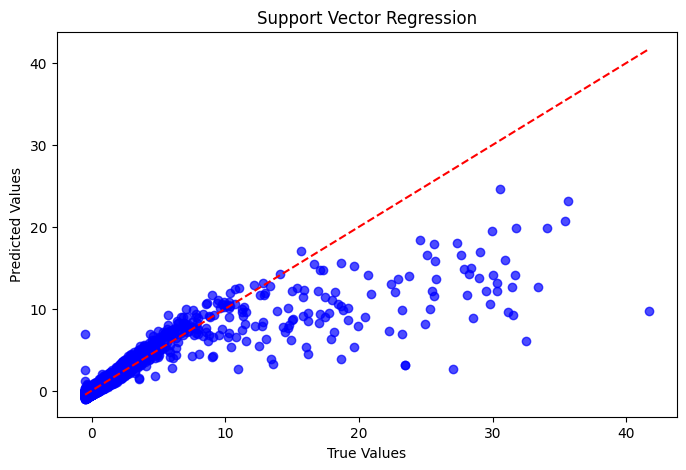

In [ ]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a', 'mu', 'tau', 'a0'], axis=1)
Y = fitting_results_df_scaled.filter(['a']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit a basic SVR model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, Y_train)

# Show the prediction power before tuning
pre_tuned_pred = svr_model.predict(X_test)
print("Pre Tuned MAE: {0}".format(mean_absolute_error(Y_test, pre_tuned_pred)))
print("Pre Tuned MSE: {0}".format(mean_squared_error(Y_test, pre_tuned_pred)))
print("Pre Tuned R2: {0}".format(r2_score(Y_test, pre_tuned_pred)))

param_grid = {
    'C': [1, 10],
    'gamma': [0.1, 1, 'scale'],
    'epsilon': [0.1, 0.5]
}

# Tune hyperparameters using param_grid print the best ones
grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)

# Show the prediction power after tuning using best estimators
best_svr_model = grid_search.best_estimator_
post_tuned_pred = best_svr_model.predict(X_test)
print("Post Tuned MAE: {0}".format(mean_absolute_error(Y_test, post_tuned_pred)))
print("Post Tuned MSE: {0}".format(mean_squared_error(Y_test, post_tuned_pred)))
print("Post Tuned R2: {0}".format(r2_score(Y_test, post_tuned_pred)))

# Plot the predictions
plt.figure(figsize=(8,5))
plt.scatter(Y_test, post_tuned_pred, alpha=0.7, color='blue')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], '--', color='red')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Support Vector Regression")
plt.show()

## Pipeline 3.2 feature mu

Pre Tuned MAE: 0.46233529514910837
Pre Tuned MSE: 3.889058228495546
Pre Tuned R2: 0.5784247352373226
Best Parameters:  {'C': 10, 'epsilon': 0.5, 'gamma': 1}
Post Tuned MAE: 0.49944153516744133
Post Tuned MSE: 2.0140272198526166
Post Tuned R2: 0.7816787487964508


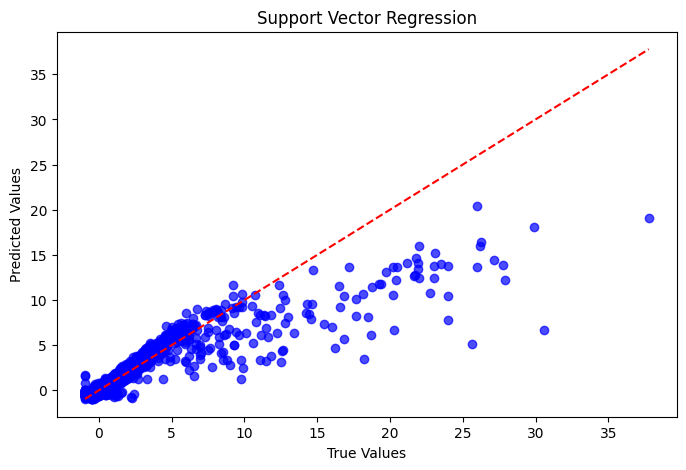

In [ ]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a', 'mu', 'tau', 'a0'], axis=1)
Y = fitting_results_df_scaled.filter(['mu']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit a basic SVR model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, Y_train)

# Show the prediction power before tuning
pre_tuned_pred = svr_model.predict(X_test)
print("Pre Tuned MAE: {0}".format(mean_absolute_error(Y_test, pre_tuned_pred)))
print("Pre Tuned MSE: {0}".format(mean_squared_error(Y_test, pre_tuned_pred)))
print("Pre Tuned R2: {0}".format(r2_score(Y_test, pre_tuned_pred)))

param_grid = {
    'C': [1, 10],
    'gamma': [0.1, 1, 'scale'],
    'epsilon': [0.1, 0.5]
}

# Tune hyperparameters using param_grid print the best ones
grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)

# Show the prediction power after tuning using best estimators
best_svr_model = grid_search.best_estimator_
post_tuned_pred = best_svr_model.predict(X_test)
print("Post Tuned MAE: {0}".format(mean_absolute_error(Y_test, post_tuned_pred)))
print("Post Tuned MSE: {0}".format(mean_squared_error(Y_test, post_tuned_pred)))
print("Post Tuned R2: {0}".format(r2_score(Y_test, post_tuned_pred)))

# Plot the predictions
plt.figure(figsize=(8,5))
plt.scatter(Y_test, post_tuned_pred, alpha=0.7, color='blue')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], '--', color='red')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Support Vector Regression")
plt.show()

## Pipeline 3.3 feature tau

Pre Tuned MAE: 0.1088876203799155
Pre Tuned MSE: 0.06790867520509866
Pre Tuned R2: 0.9288237143576956
Best Parameters:  {'C': 10, 'epsilon': 0.1, 'gamma': 1}
Post Tuned MAE: 0.08224737608494143
Post Tuned MSE: 0.03108742299732997
Post Tuned R2: 0.9674167211706264


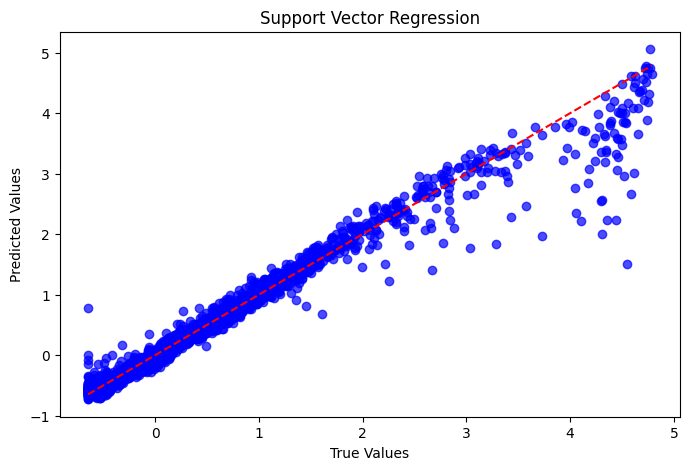

In [ ]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a', 'mu', 'tau', 'a0'], axis=1)
Y = fitting_results_df_scaled.filter(['tau']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit a basic SVR model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, Y_train)

# Show the prediction power before tuning
pre_tuned_pred = svr_model.predict(X_test)
print("Pre Tuned MAE: {0}".format(mean_absolute_error(Y_test, pre_tuned_pred)))
print("Pre Tuned MSE: {0}".format(mean_squared_error(Y_test, pre_tuned_pred)))
print("Pre Tuned R2: {0}".format(r2_score(Y_test, pre_tuned_pred)))

param_grid = {
    'C': [1, 10],
    'gamma': [0.1, 1, 'scale'],
    'epsilon': [0.1, 0.5]
}

# Tune hyperparameters using param_grid print the best ones
grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)

# Show the prediction power after tuning using best estimators
best_svr_model = grid_search.best_estimator_
post_tuned_pred = best_svr_model.predict(X_test)
print("Post Tuned MAE: {0}".format(mean_absolute_error(Y_test, post_tuned_pred)))
print("Post Tuned MSE: {0}".format(mean_squared_error(Y_test, post_tuned_pred)))
print("Post Tuned R2: {0}".format(r2_score(Y_test, post_tuned_pred)))

# Plot the predictions
plt.figure(figsize=(8,5))
plt.scatter(Y_test, post_tuned_pred, alpha=0.7, color='blue')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], '--', color='red')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Support Vector Regression")
plt.show()

## Pipeline 3.4 feature a0

Pre Tuned MAE: 1.013733493482334
Pre Tuned MSE: 4.77612465188625
Pre Tuned R2: 0.36082060333331945
Best Parameters:  {'C': 10, 'epsilon': 0.5, 'gamma': 1}
Post Tuned MAE: 0.983131209585512
Post Tuned MSE: 3.476756489771765
Post Tuned R2: 0.5347124965401323


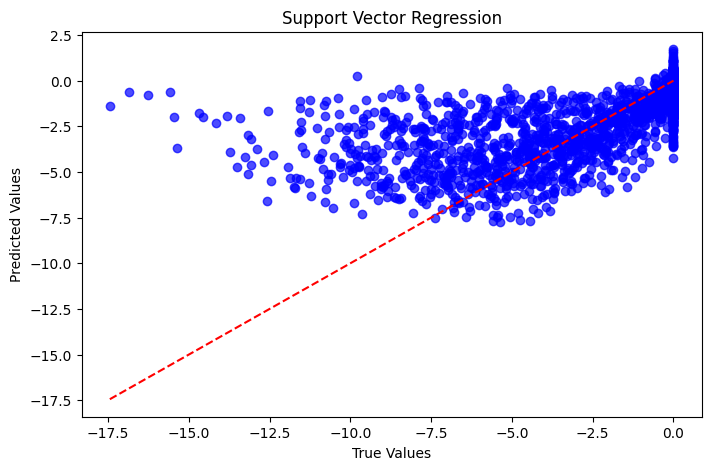

In [ ]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a', 'mu', 'tau', 'a0'], axis=1)
Y = fitting_results_df_scaled.filter(['a0']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit a basic SVR model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, Y_train)

# Show the prediction power before tuning
pre_tuned_pred = svr_model.predict(X_test)
print("Pre Tuned MAE: {0}".format(mean_absolute_error(Y_test, pre_tuned_pred)))
print("Pre Tuned MSE: {0}".format(mean_squared_error(Y_test, pre_tuned_pred)))
print("Pre Tuned R2: {0}".format(r2_score(Y_test, pre_tuned_pred)))

param_grid = {
    'C': [1, 10],
    'gamma': [0.1, 1, 'scale'],
    'epsilon': [0.1, 0.5]
}

# Tune hyperparameters using param_grid print the best ones
grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)

# Show the prediction power after tuning using best estimators
best_svr_model = grid_search.best_estimator_
post_tuned_pred = best_svr_model.predict(X_test)
print("Post Tuned MAE: {0}".format(mean_absolute_error(Y_test, post_tuned_pred)))
print("Post Tuned MSE: {0}".format(mean_squared_error(Y_test, post_tuned_pred)))
print("Post Tuned R2: {0}".format(r2_score(Y_test, post_tuned_pred)))

# Plot the predictions
plt.figure(figsize=(8,5))
plt.scatter(Y_test, post_tuned_pred, alpha=0.7, color='blue')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], '--', color='red')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Support Vector Regression")
plt.show()

# Pipeline 3 Overall Evaluation

Definite improvement overall with the metrics as we increase R2 score, decrease MSE and minorly increase in MAE over the 4 features. The issue is the amount of time it took as the param_grid increases, so we really had to limit the number of hyperparameters to test. What we have is good, but could be better, lets see how a different model performs finally.

# Pipeline 4 Random Forest Regression w/ tuned hyperparameters

Our final pipeline will look at Random Forest Regression with tuned hyperparameters similar to that of the 3rd pipeline. Hopefully, an ensamble method will be more adaptable to both linear and non-linear patterns.

## Pipeline 4.1 feature a

Pre Tuned OOB Score:  0.9767464008033151
Pre Tuned MSE: 0.34308943638389644
Pre Tuned R2: 0.9739721413633039
Best Parameters:  {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Post Tuned OOB Score:  0.9704401378611036
Post Tuned MSE: 0.4065678409047028
Post Tuned R2: 0.9691564671858518


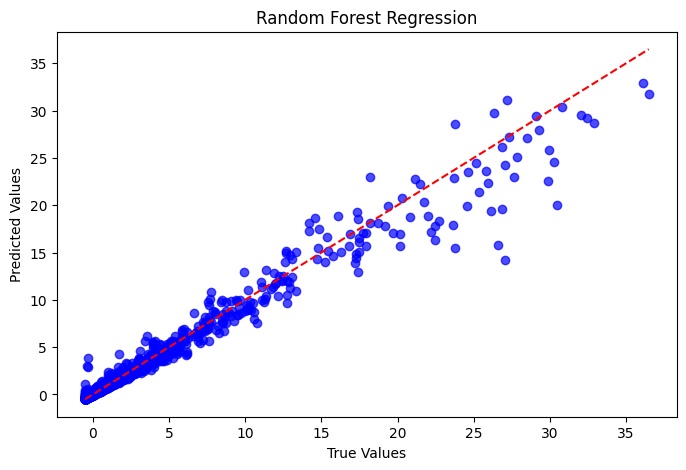

In [14]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a', 'mu', 'tau', 'a0'], axis=1)
Y = fitting_results_df_scaled.filter(['a']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit basic RFR, with Out Of Bag scoring to evaluate unseen data on the model
rf_regressor = RandomForestRegressor(oob_score=True)
rf_regressor.fit(X_train, Y_train)

# Print pre-tuned metrics
pre_oob_score = rf_regressor.oob_score_
print("Pre Tuned OOB Score: ", pre_oob_score)

pre_rf_pred = rf_regressor.predict(X_test)
print("Pre Tuned MSE: {0}".format(mean_squared_error(Y_test, pre_rf_pred)))
print("Pre Tuned R2: {0}".format(r2_score(Y_test, pre_rf_pred)))

# Search grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search RFR for best parameters
grid_search = GridSearchCV(RandomForestRegressor(oob_score=True), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)

# Print post-tuned metrics
best_rf_regressor = grid_search.best_estimator_
post_oob_score = best_rf_regressor.oob_score_
print("Post Tuned OOB Score: ", post_oob_score)

post_rf_pred = best_rf_regressor.predict(X_test)
print("Post Tuned MSE: {0}".format(mean_squared_error(Y_test, post_rf_pred)))
print("Post Tuned R2: {0}".format(r2_score(Y_test, post_rf_pred)))

# Plot the predictions
plt.figure(figsize=(8,5))
plt.scatter(Y_test, post_rf_pred, alpha=0.7, color='blue')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], '--', color='red')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression")
plt.show()

## Pipeline 4.2 feature mu

Pre Tuned OOB Score:  0.9748464015676882
Pre Tuned MSE: 0.25956383419256907
Pre Tuned R2: 0.9756179563103133
Best Parameters:  {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Post Tuned OOB Score:  0.9632179127182668
Post Tuned MSE: 0.30958987353064243
Post Tuned R2: 0.9709187767017321


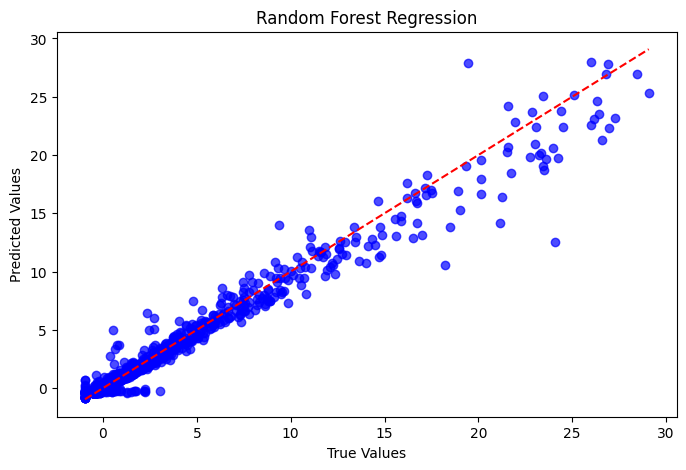

In [15]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a', 'mu', 'tau', 'a0'], axis=1)
Y = fitting_results_df_scaled.filter(['mu']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit basic RFR, with Out Of Bag scoring to evaluate unseen data on the model
rf_regressor = RandomForestRegressor(oob_score=True)
rf_regressor.fit(X_train, Y_train)

# Print pre-tuned metrics
pre_oob_score = rf_regressor.oob_score_
print("Pre Tuned OOB Score: ", pre_oob_score)

pre_rf_pred = rf_regressor.predict(X_test)
print("Pre Tuned MSE: {0}".format(mean_squared_error(Y_test, pre_rf_pred)))
print("Pre Tuned R2: {0}".format(r2_score(Y_test, pre_rf_pred)))

# Search grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search RFR for best parameters
grid_search = GridSearchCV(RandomForestRegressor(oob_score=True), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)

# Print post-tuned metrics
best_rf_regressor = grid_search.best_estimator_
post_oob_score = best_rf_regressor.oob_score_
print("Post Tuned OOB Score: ", post_oob_score)

post_rf_pred = best_rf_regressor.predict(X_test)
print("Post Tuned MSE: {0}".format(mean_squared_error(Y_test, post_rf_pred)))
print("Post Tuned R2: {0}".format(r2_score(Y_test, post_rf_pred)))

# Plot the predictions
plt.figure(figsize=(8,5))
plt.scatter(Y_test, post_rf_pred, alpha=0.7, color='blue')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], '--', color='red')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression")
plt.show()

## Pipeline 4.3 feature tau

Pre Tuned OOB Score:  0.9935524970807628
Pre Tuned MSE: 0.010964708125533367
Pre Tuned R2: 0.9897332177726458
Best Parameters:  {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Post Tuned OOB Score:  0.987064549846291
Post Tuned MSE: 0.015446125137787786
Post Tuned R2: 0.9855370520372685


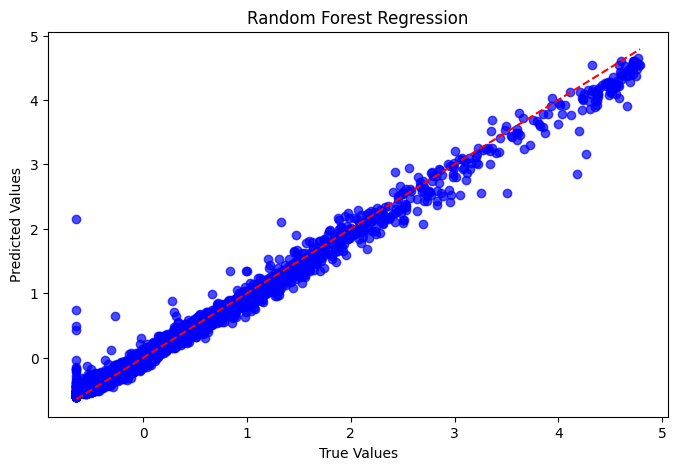

In [16]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a', 'mu', 'tau', 'a0'], axis=1)
Y = fitting_results_df_scaled.filter(['tau']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit basic RFR, with Out Of Bag scoring to evaluate unseen data on the model
rf_regressor = RandomForestRegressor(oob_score=True)
rf_regressor.fit(X_train, Y_train)

# Print pre-tuned metrics
pre_oob_score = rf_regressor.oob_score_
print("Pre Tuned OOB Score: ", pre_oob_score)

pre_rf_pred = rf_regressor.predict(X_test)
print("Pre Tuned MSE: {0}".format(mean_squared_error(Y_test, pre_rf_pred)))
print("Pre Tuned R2: {0}".format(r2_score(Y_test, pre_rf_pred)))

# Search grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search RFR for best parameters
grid_search = GridSearchCV(RandomForestRegressor(oob_score=True), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)

# Print post-tuned metrics
best_rf_regressor = grid_search.best_estimator_
post_oob_score = best_rf_regressor.oob_score_
print("Post Tuned OOB Score: ", post_oob_score)

post_rf_pred = best_rf_regressor.predict(X_test)
print("Post Tuned MSE: {0}".format(mean_squared_error(Y_test, post_rf_pred)))
print("Post Tuned R2: {0}".format(r2_score(Y_test, post_rf_pred)))

# Plot the predictions
plt.figure(figsize=(8,5))
plt.scatter(Y_test, post_rf_pred, alpha=0.7, color='blue')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], '--', color='red')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression")
plt.show()

## Pipeline 4.4 feature a0

Pre Tuned OOB Score:  0.6995509556940741
Pre Tuned MSE: 2.3363934141484166
Pre Tuned R2: 0.6984814722810662
Best Parameters:  {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Post Tuned OOB Score:  0.6464390940722904
Post Tuned MSE: 2.729292434178299
Post Tuned R2: 0.6477766837192471


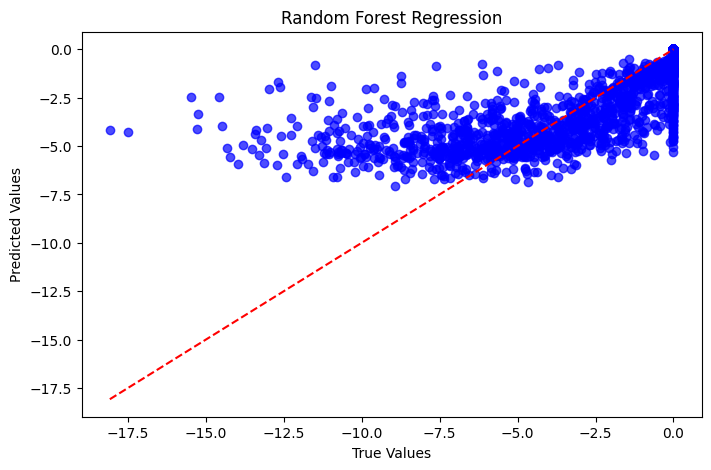

In [17]:
# Splitting data into X: not target var and Y: target var
X = fitting_results_df_scaled.drop(['a', 'mu', 'tau', 'a0'], axis=1)
Y = fitting_results_df_scaled.filter(['a0']).values.ravel()

# Split our data into 80% train 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Fit basic RFR, with Out Of Bag scoring to evaluate unseen data on the model
rf_regressor = RandomForestRegressor(oob_score=True)
rf_regressor.fit(X_train, Y_train)

# Print pre-tuned metrics
pre_oob_score = rf_regressor.oob_score_
print("Pre Tuned OOB Score: ", pre_oob_score)

pre_rf_pred = rf_regressor.predict(X_test)
print("Pre Tuned MSE: {0}".format(mean_squared_error(Y_test, pre_rf_pred)))
print("Pre Tuned R2: {0}".format(r2_score(Y_test, pre_rf_pred)))

# Search grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search RFR for best parameters
grid_search = GridSearchCV(RandomForestRegressor(oob_score=True), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, Y_train)
print("Best Parameters: ", grid_search.best_params_)

# Print post-tuned metrics
best_rf_regressor = grid_search.best_estimator_
post_oob_score = best_rf_regressor.oob_score_
print("Post Tuned OOB Score: ", post_oob_score)

post_rf_pred = best_rf_regressor.predict(X_test)
print("Post Tuned MSE: {0}".format(mean_squared_error(Y_test, post_rf_pred)))
print("Post Tuned R2: {0}".format(r2_score(Y_test, post_rf_pred)))

# Plot the predictions
plt.figure(figsize=(8,5))
plt.scatter(Y_test, post_rf_pred, alpha=0.7, color='blue')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], '--', color='red')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression")
plt.show()

# Pipeline 4 Overall Evaluation

For the final pipeline, it seems like Random Forest Regressor has performed the best as a model for our data. However, a few metrics are a bit confusing, regarding the differences between pre-tuned and post-tuned metrics. The change is rather insignifficant, with feature a0 specifically seeming like tuning the parameter made the model worse. I believe there are still overfitting issues and that something is wrong when it comes to trying to predict a0. This will be the aim for future work on this project.